# Bayesian Curl Analysis

## Background

This project analyzes approximately 13 months of my bayesian curl progress at the gym.

## What does this project aim to do?

**Track my progress**
- How many reps do I do per set and per session before I progress to the next weight setting?
- How does the difference in weight setting jumps (2kg or 5kg; see below for explanation) influence this?

**Discover what influences progress**
- Do rest pause reps or drop sets have an influence?
- Did taking one month off from bayesian curls and doing basic curls to allow my rhomboid to heal have an effect?
- What are the effects of factors such as bodyweight, time on a weight, and previous performance?

## What is a bayesian curl?

A bayesian curl is a bicep curl exercise performed on a cable machine. The lifter stands and faces away from the machine. At the starting position, the shoulders are extended behind the body, causing the biceps to be in a more stretched position. The lifter then flexes the arm at the elbow, bringing the wrists towards the shoulders. The elbow is then extended and the arms return to the starting position.

## About the gym setup

All recorded bayesian curls were performed on a cable machine. The machine has two cables, each attached to its own stack of plates. Plates increase by 2kg, until they get to the 27kg setting. After that, they increase by 5kg, so the setting following 27kg is 32kg. A standard handle attachment was used for all curls.

## Limitations

The data records whether or not the bayesian curls were the first or second bicep exercise of the day, but it does not record where within the entire routine they were performed. For example, it might be the first exercise of the day, or the second following a shoulder press, or even the fifth after several other exercises. That being said, it often has been the second exercise of the day, especially if it is the first (or only) bicep isolation exercise being performed.

Most workouts have been performed early in the morning, but there are cases where they have been performed later. This is not recorded in the data. However, a few cases occurred where a shoulder and arm routine was performed either the same day or even right after a chest and back routine (approximately three times).

**Last updated:** July 2026
**Author:** Anthony DiSorbo

# Variable Dictionary

| Variable | Description |
|---|---|
| `date` | Date the session occurred, in `YYYY-MM-DD` format. |
| `set` | Set number within that session (resets to 1 for each new date). |
| `weight` | Weight (kg) used for the main portion of the set. Each arm's stack is independent; each arm moved this weight, not a combined total. |
| `reps` | Reps completed at `weight`, before any rest-pause or drop. |
| `rest_pause_reps` | Additional reps performed after a brief (~15sec) rest-pause, at the same `weight`. `0` if no rest-pause was used. |
| `drop_weight` | Weight (kg) dropped mid-set for a drop set. `0` if no drop occurred. |
| `drop_reps` | Reps completed at `drop_weight`. `0` if no drop occurred. |
| `arm` | Which arm(s) performed the set: `both`, `left`, or `right`. A missing arm for a given set/date means that arm wasn't trained that set (not a 0-rep attempt). |
| `exercise_order` | Whether bayesian curl was the `first` or `second` bicep exercise performed that day. |
| `note` | Free-text context (e.g. equipment issues, injuries, supersets, extra rest). Blank when nothing notable. |

**Notes:**
- Total reps for a set = `reps + rest_pause_reps` (main portion) plus `drop_reps` at `drop_weight` if a drop occurred.
- A small number of sets included a second drop stage beyond what `drop_weight`/`drop_reps` can capture; those are recorded only in `note` (flagged: 2025-12-20 set 3, 2026-07-11 set 3).

In [ ]:
#Install libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
import statsmodels.api as sm

In [ ]:
#Import .csv data file and display top five rows

df = pd.read_csv('bayesian_curls.csv')

df.head()

,date,set,weight,reps,rest_pause_reps,drop_weight,drop_reps,arm,exercise_order,note
0,2025-06-08,1,11,12,0,0,0,both,second,NaN
1,2025-06-08,2,11,12,0,0,0,both,second,NaN
2,2025-06-08,3,11,11,0,0,0,both,second,NaN
3,2025-06-12,1,11,14,0,0,0,both,second,NaN
4,2025-06-12,2,11,14,0,0,0,both,second,NaN


In [ ]:
#Without accounting for which set, overall perfromance averages

df.describe()

,date,set,weight,reps,rest_pause_reps,drop_weight,drop_reps,bodyweight
count,358,358.000000,358.000000,358.000000,358.000000,358.000000,358.000000,358.000000
mean,2025-12-10 02:36:52.290502,2.159218,23.139665,9.974860,0.100559,0.614525,0.078212,72.879888
min,2025-06-08 00:00:00,1.000000,11.000000,3.000000,0.000000,0.000000,0.000000,70.000000
25%,2025-08-27 00:00:00,1.000000,18.000000,8.000000,0.000000,0.000000,0.000000,71.000000
50%,2025-12-01 00:00:00,2.000000,25.000000,10.000000,0.000000,0.000000,0.000000,72.750000
75%,2026-03-18 00:00:00,3.000000,27.000000,12.000000,0.000000,0.000000,0.000000,74.500000
max,2026-07-25 00:00:00,5.000000,32.000000,19.000000,4.000000,27.000000,6.000000,76.000000
std,NaN,0.972917,5.795540,2.915607,0.486167,3.682347,0.507120,1.896359


## EDA

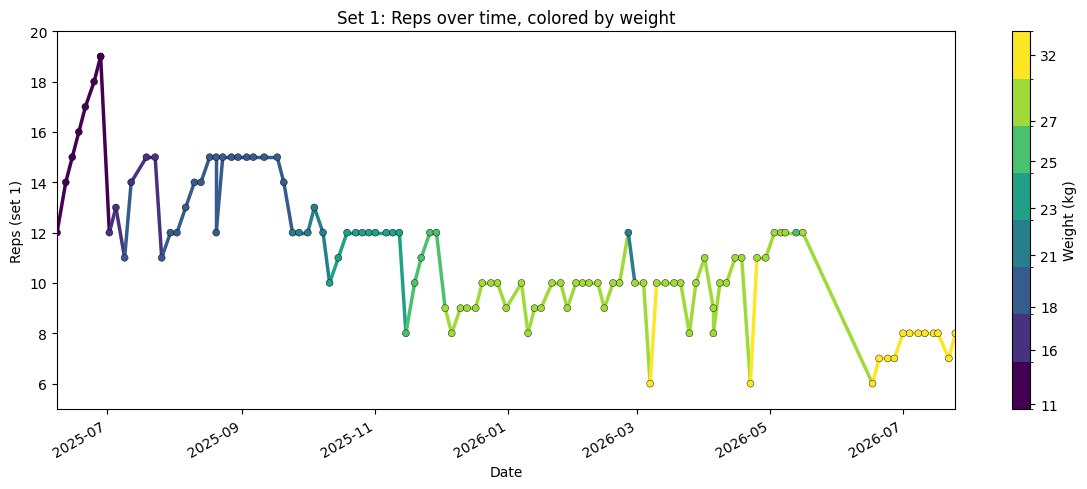

In [ ]:
# ============================================================
# --- Reps over time for Set 1, tracking weight ---
# ============================================================
# --- filter and prep ---
dset1 = df[df['set'] == 1].copy()
dset1['date'] = pd.to_datetime(dset1['date'])
dset1 = dset1.sort_values('date').reset_index(drop=True)
x = dset1['date'].values
y = dset1['reps'].values
w = dset1['weight'].values
# --- build line segments between consecutive points ---
points = np.array([plt.matplotlib.dates.date2num(x), y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
# #COLOR_SCALE: discrete scale matching actual weight settings
weight_levels = [11, 16, 18, 21, 23, 25, 27, 32]  # ascending order, whole-number stack settings
cmap = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(weight_levels))))
boundaries = [w - 0.5 for w in weight_levels] + [weight_levels[-1] + 0.5]
norm = BoundaryNorm(boundaries, cmap.N)
# #COLOR_SCALE end
lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(w[:-1])
lc.set_linewidth(2.5)
# --- plot ---
fig, ax = plt.subplots(figsize=(12, 5))
line = ax.add_collection(lc)
ax.scatter(x, y, c=w, cmap=cmap, norm=norm, s=25, zorder=3, edgecolor='k', linewidth=0.3)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min() - 1, y.max() + 1)
ax.xaxis_date()
fig.autofmt_xdate()
ax.set_xlabel('Date')
ax.set_ylabel('Reps (set 1)')
ax.set_title('Set 1: Reps over time, colored by weight')
cbar = fig.colorbar(line, ax=ax, ticks=weight_levels)
cbar.set_label('Weight (kg)')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/set1_reps_weight.png', dpi=150)
plt.show()

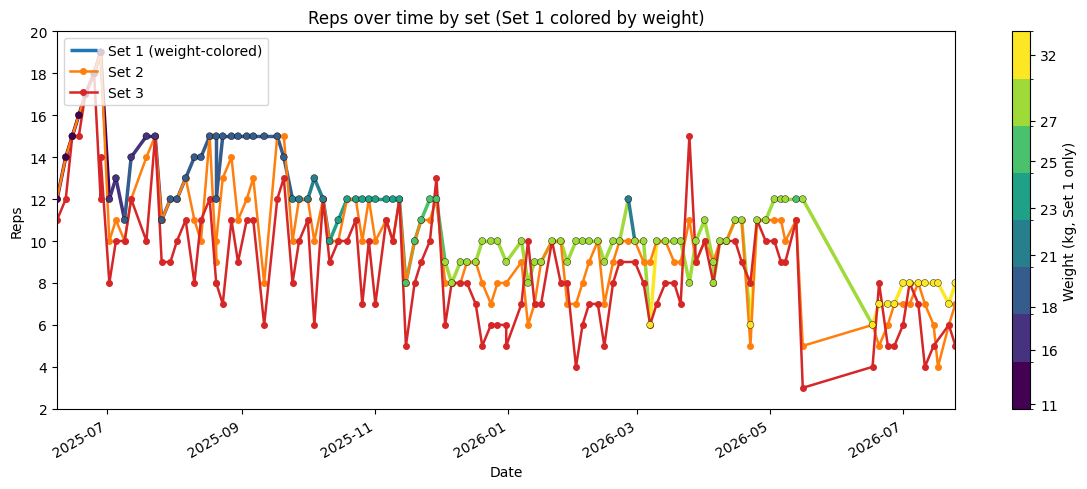

In [ ]:
# =============================================================
# --- Reps over time for all sets, tracking weight for Set 1---
# =============================================================
# --- filter and prep for each set ---
dset2 = df[df['set'] == 2].copy()
dset3 = df[df['set'] == 3].copy()
for d in (dset1, dset2, dset3):
    d['date'] = pd.to_datetime(d['date'])
    d.sort_values('date', inplace=True)
    d.reset_index(drop=True, inplace=True)
# --- set 1: line colored by weight ---
x1 = dset1['date'].values
y1 = dset1['reps'].values
w1 = dset1['weight'].values
points = np.array([plt.matplotlib.dates.date2num(x1), y1]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
# #COLOR_SCALE: discrete scale matching actual weight settings
weight_levels = [11, 16, 18, 21, 23, 25, 27, 32]  # ascending order, whole-number stack settings
cmap = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(weight_levels))))
boundaries = [w - 0.5 for w in weight_levels] + [weight_levels[-1] + 0.5]
norm = BoundaryNorm(boundaries, cmap.N)
# #COLOR_SCALE end
lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(w1[:-1])
lc.set_linewidth(2.5)
lc.set_label('Set 1 (weight-colored)')
# --- plot ---
fig, ax = plt.subplots(figsize=(12, 5))
line = ax.add_collection(lc)
ax.scatter(x1, y1, c=w1, cmap=cmap, norm=norm, s=25, zorder=3, edgecolor='k', linewidth=0.3)
# set 2 and set 3: plain reps-only lines
ax.plot(dset2['date'], dset2['reps'], color='tab:orange', linewidth=1.8,
        marker='o', markersize=4, label='Set 2')
ax.plot(dset3['date'], dset3['reps'], color='tab:red', linewidth=1.8,
        marker='o', markersize=4, label='Set 3')
# axis limits need to account for all three sets now
all_dates = pd.concat([dset1['date'], dset2['date'], dset3['date']])
all_reps = pd.concat([dset1['reps'], dset2['reps'], dset3['reps']])
ax.set_xlim(all_dates.min(), all_dates.max())
ax.set_ylim(all_reps.min() - 1, all_reps.max() + 1)
ax.xaxis_date()
fig.autofmt_xdate()
ax.set_xlabel('Date')
ax.set_ylabel('Reps')
ax.set_title('Reps over time by set (Set 1 colored by weight)')
ax.legend(loc='upper left')
cbar = fig.colorbar(line, ax=ax, ticks=weight_levels)
cbar.set_label('Weight (kg, Set 1 only)')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/sets123_reps_weight.png', dpi=150)
plt.show()

### Pattern Emerging

Sets 2 and 3 are somewhat following the same pattern, with set 3 reps just being a little lower. Let's see a cleaner picture by averaging sets 2 and 3 together and make one line.

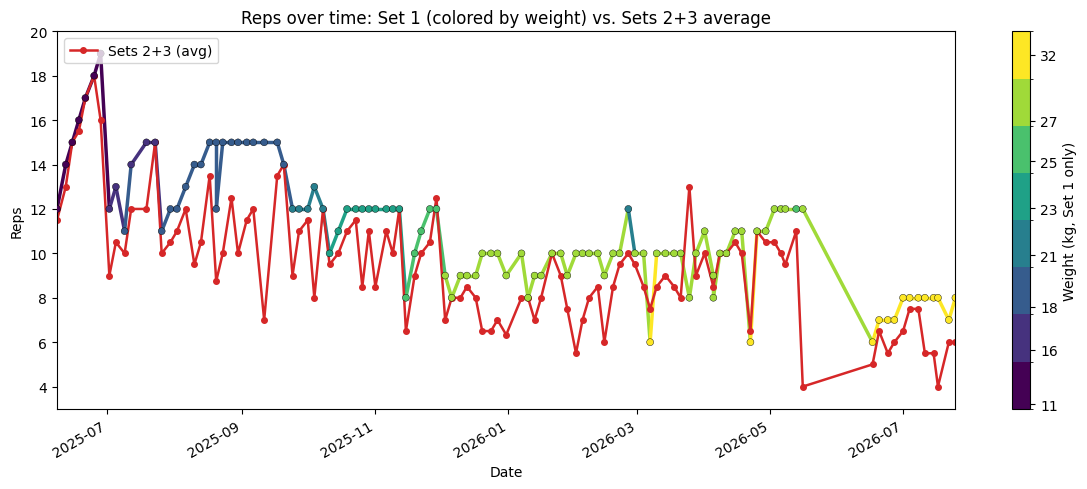

In [ ]:
# ===================================================================================================
# --- Reps over time for all sets, tracking weight for Set 1, averaging Set 2 and 3 reps together ---
# ===================================================================================================
# --- filter and prep ---
dset23 = df[df['set'].isin([2, 3])].copy()
dset1['date'] = pd.to_datetime(dset1['date'])
dset23['date'] = pd.to_datetime(dset23['date'])
dset1.sort_values('date', inplace=True)
dset1.reset_index(drop=True, inplace=True)
# average reps across sets 2 and 3, per date
dset23_avg = dset23.groupby('date', as_index=False)['reps'].mean()
dset23_avg.sort_values('date', inplace=True)
dset23_avg.reset_index(drop=True, inplace=True)
# --- set 1: line colored by weight ---
x1 = dset1['date'].values
y1 = dset1['reps'].values
w1 = dset1['weight'].values
points = np.array([plt.matplotlib.dates.date2num(x1), y1]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
# #COLOR_SCALE: discrete scale matching actual weight settings
weight_levels = [11, 16, 18, 21, 23, 25, 27, 32]  # ascending order, whole-number stack settings
cmap = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(weight_levels))))
boundaries = [w - 0.5 for w in weight_levels] + [weight_levels[-1] + 0.5]
norm = BoundaryNorm(boundaries, cmap.N)
# #COLOR_SCALE end
lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(w1[:-1])
lc.set_linewidth(2.5)
# --- plot ---
fig, ax = plt.subplots(figsize=(12, 5))
line = ax.add_collection(lc)
ax.scatter(x1, y1, c=w1, cmap=cmap, norm=norm, s=25, zorder=3, edgecolor='k', linewidth=0.3)
# sets 2+3 averaged: single red line
ax.plot(dset23_avg['date'], dset23_avg['reps'], color='tab:red', linewidth=1.8,
        marker='o', markersize=4, label='Sets 2+3 (avg)')
# axis limits
all_dates = pd.concat([dset1['date'], dset23_avg['date']])
all_reps = pd.concat([dset1['reps'], dset23_avg['reps']])
ax.set_xlim(all_dates.min(), all_dates.max())
ax.set_ylim(all_reps.min() - 1, all_reps.max() + 1)
ax.xaxis_date()
fig.autofmt_xdate()
ax.set_xlabel('Date')
ax.set_ylabel('Reps')
ax.set_title('Reps over time: Set 1 (colored by weight) vs. Sets 2+3 average')
ax.legend(loc='upper left')
cbar = fig.colorbar(line, ax=ax, ticks=weight_levels)
cbar.set_label('Weight (kg, Set 1 only)')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/set1_vs_avg23_reps_weight.png', dpi=150)
plt.show()

### The Set-1 Ceiling, and the Cost of Every New Weight

The average of sets 2 and 3 zigzags within a 3-rep range, usually 1-2 reps below set 1. That average eventually catches up to set 1, and that's when I bump the weight. It's a conscious call, but one that also shows real variance in sets 2 and 3 while set 1 climbs to a flat max.

27kg to 32kg took the longest of any jump. I'd settled on 10 reps as my set-1 ceiling at 27kg. Around February 2026, my sets 2/3 average caught up to set 1, but I didn't increase the weight until the next catch-up in early March.

My first attempt at 32kg landed at 6 reps (the red line reading a bit higher there is likely from doing sets 2/3 at 27kg instead). After that, sets 2/3 tracked set 1 again. My second attempt, in late April, also came in at 6 reps, even after pushing 27kg back up to 12 reps in set 1 first. Right after that, an injury forced a month on standard curls.

When I returned to bayesian curls, I went back in at 32kg (6 reps again). This time I stuck with it, and over 6 weeks worked up to a max of 8. In hindsight, I may have been ready for 32kg back in April; I just let the repeated 6-rep sets discourage me. And clearly, grinding 27kg up to 11 reps did nothing to change the outcome on that second 32kg attempt; it was still 6.

Across every jump (23kg, 25kg, 27kg, 32kg) there's a consistent ~2-rep drop in both starting and eventual max. So even though 32kg started at 6 instead of the 8 that other tiers started at, that doesn't mean my ceiling there should be 2 reps lower too. Going by the pattern, I should still be aiming for 10 reps on set 1 at 32kg.

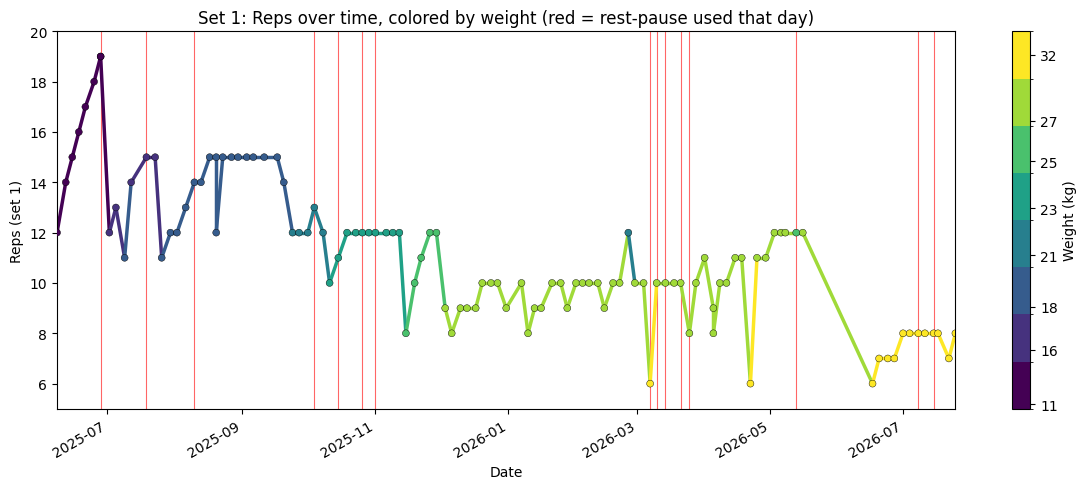

In [ ]:
# =======================================================
# --- Rest Pauses and Set 1 reps and weight over time ---
# =======================================================


# #COLOR_SCALE: discrete scale matching actual weight settings
weight_levels = [11, 16, 18, 21, 23, 25, 27, 32]  # ascending order, whole-number stack settings
cmap = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(weight_levels))))
boundaries = [w - 0.5 for w in weight_levels] + [weight_levels[-1] + 0.5]
norm = BoundaryNorm(boundaries, cmap.N)
# #COLOR_SCALE end

# --- set 1: line colored by weight ---
points = np.array([plt.matplotlib.dates.date2num(x1), y1]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(w1[:-1])
lc.set_linewidth(2.5)

# --- rest-pause dates (any set that day had a rest-pause rep) ---
rp_dates = pd.to_datetime(df.loc[df['rest_pause_reps'] > 0, 'date'].unique())

# --- plot ---
fig, ax = plt.subplots(figsize=(12, 5))

line = ax.add_collection(lc)
ax.scatter(x1, y1, c=w1, cmap=cmap, norm=norm, s=25, zorder=3, edgecolor='k', linewidth=0.3)

for rp_date in rp_dates:
    ax.axvline(rp_date, color='red', linewidth=0.8, alpha=0.6, zorder=1)

ax.set_xlim(x1.min(), x1.max())
ax.set_ylim(y1.min() - 1, y1.max() + 1)
ax.xaxis_date()
fig.autofmt_xdate()

ax.set_xlabel('Date')
ax.set_ylabel('Reps (set 1)')
ax.set_title('Set 1: Reps over time, colored by weight (red = rest-pause used that day)')

cbar = fig.colorbar(line, ax=ax, ticks=weight_levels)
cbar.set_label('Weight (kg)')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/set1_reps_weight_restpause.png', dpi=150)
plt.show()

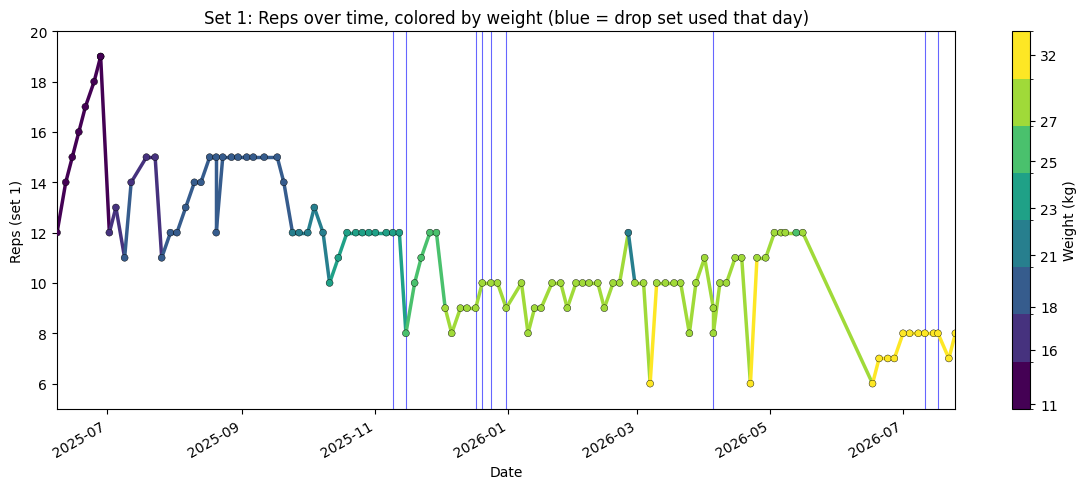

In [ ]:
# =======================================================
# --- Drop sets and Set 1 reps and weight over time ---
# =======================================================

# #COLOR_SCALE: discrete scale matching actual weight settings
weight_levels = [11, 16, 18, 21, 23, 25, 27, 32]  # ascending order, whole-number stack settings
cmap = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(weight_levels))))
boundaries = [w - 0.5 for w in weight_levels] + [weight_levels[-1] + 0.5]
norm = BoundaryNorm(boundaries, cmap.N)
# #COLOR_SCALE end

# --- set 1: line colored by weight ---
points = np.array([plt.matplotlib.dates.date2num(x1), y1]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(w1[:-1])
lc.set_linewidth(2.5)

# --- drop-set dates (any set that day had a drop) ---
drop_dates = pd.to_datetime(df.loc[df['drop_reps'] > 0, 'date'].unique())

# --- plot ---
fig, ax = plt.subplots(figsize=(12, 5))

line = ax.add_collection(lc)
ax.scatter(x1, y1, c=w1, cmap=cmap, norm=norm, s=25, zorder=3, edgecolor='k', linewidth=0.3)

for drop_date in drop_dates:
    ax.axvline(drop_date, color='blue', linewidth=0.8, alpha=0.6, zorder=1)

ax.set_xlim(x1.min(), x1.max())
ax.set_ylim(y1.min() - 1, y1.max() + 1)
ax.xaxis_date()
fig.autofmt_xdate()

ax.set_xlabel('Date')
ax.set_ylabel('Reps (set 1)')
ax.set_title('Set 1: Reps over time, colored by weight (blue = drop set used that day)')

cbar = fig.colorbar(line, ax=ax, ticks=weight_levels)
cbar.set_label('Weight (kg)')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/set1_reps_weight_dropset.png', dpi=150)
plt.show()

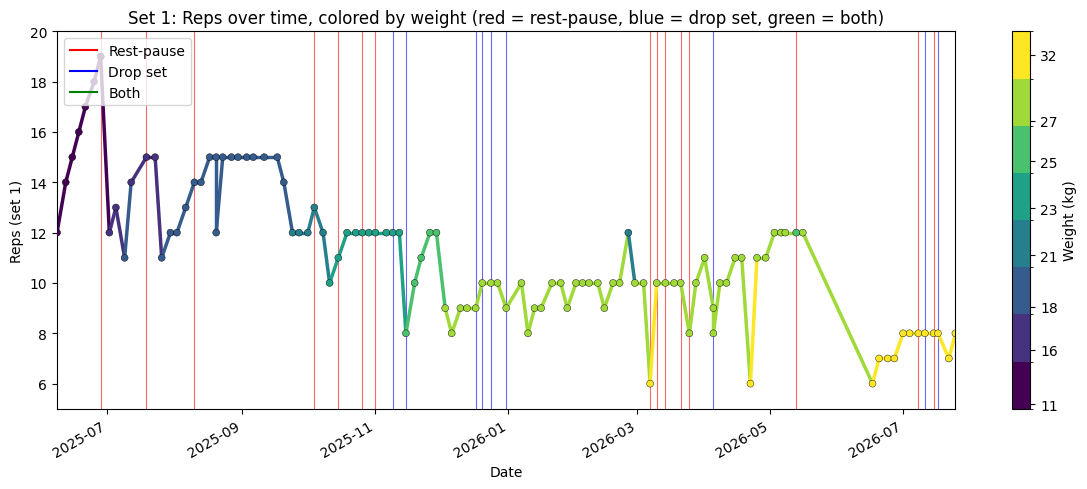

In [ ]:
# ===================================================================
# --- Rest Pauses, Drop Sets, and Set 1 reps and weight over time ---
# ===================================================================

# #COLOR_SCALE: discrete scale matching actual weight settings
weight_levels = [11, 16, 18, 21, 23, 25, 27, 32]  # ascending order, whole-number stack settings
cmap = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(weight_levels))))
boundaries = [w - 0.5 for w in weight_levels] + [weight_levels[-1] + 0.5]
norm = BoundaryNorm(boundaries, cmap.N)
# #COLOR_SCALE end
# --- set 1: line colored by weight ---
points = np.array([plt.matplotlib.dates.date2num(x1), y1]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(w1[:-1])
lc.set_linewidth(2.5)
# --- classify each date: rest-pause only, drop only, or both ---
rp_dates = set(pd.to_datetime(df.loc[df['rest_pause_reps'] > 0, 'date'].unique()))
drop_dates = set(pd.to_datetime(df.loc[df['drop_reps'] > 0, 'date'].unique()))
both_dates = rp_dates & drop_dates
rp_only_dates = rp_dates - both_dates
drop_only_dates = drop_dates - both_dates
# --- plot ---
fig, ax = plt.subplots(figsize=(12, 5))
line = ax.add_collection(lc)
ax.scatter(x1, y1, c=w1, cmap=cmap, norm=norm, s=25, zorder=3, edgecolor='k', linewidth=0.3)
for d in rp_only_dates:
    ax.axvline(d, color='red', linewidth=0.8, alpha=0.6, zorder=1)
for d in drop_only_dates:
    ax.axvline(d, color='blue', linewidth=0.8, alpha=0.6, zorder=1)
for d in both_dates:
    ax.axvline(d, color='green', linewidth=0.8, alpha=0.6, zorder=1)
legend_lines = [
    Line2D([0], [0], color='red', lw=1.5, label='Rest-pause'),
    Line2D([0], [0], color='blue', lw=1.5, label='Drop set'),
    Line2D([0], [0], color='green', lw=1.5, label='Both'),
]
ax.set_xlim(x1.min(), x1.max())
ax.set_ylim(y1.min() - 1, y1.max() + 1)
ax.xaxis_date()
fig.autofmt_xdate()
ax.set_xlabel('Date')
ax.set_ylabel('Reps (set 1)')
ax.set_title('Set 1: Reps over time, colored by weight (red = rest-pause, blue = drop set, green = both)')
ax.legend(handles=legend_lines, loc='upper left')
cbar = fig.colorbar(line, ax=ax, ticks=weight_levels)
cbar.set_label('Weight (kg)')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/set1_reps_weight_rp_drop_both.png', dpi=150)
plt.show()

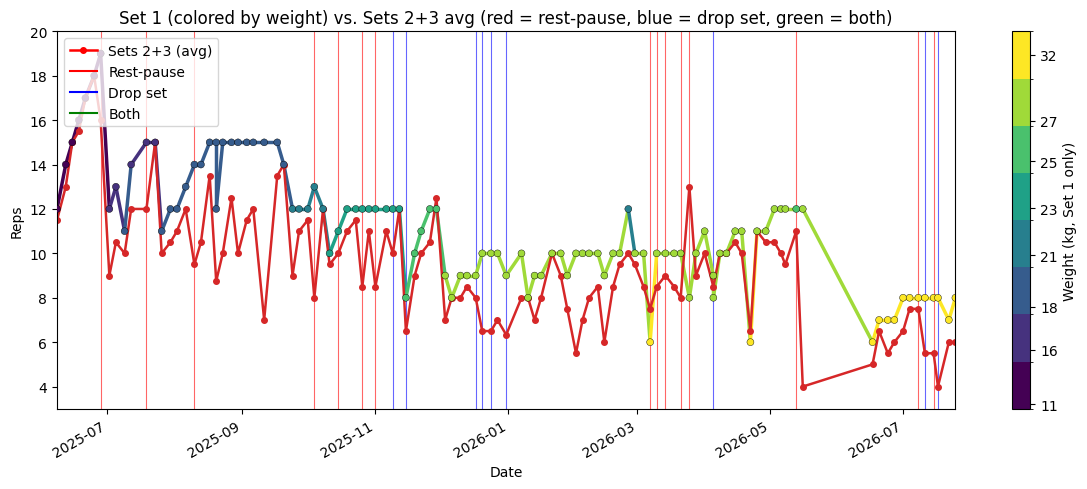

In [ ]:
# =====================================================================
# --- Rest Pauses, Drop Sets, and all set reps and weight over time ---
# =====================================================================

# #COLOR_SCALE: discrete scale matching actual weight settings
weight_levels = [11, 16, 18, 21, 23, 25, 27, 32]  # ascending order, whole-number stack settings
cmap = ListedColormap(plt.cm.viridis(np.linspace(0, 1, len(weight_levels))))
boundaries = [w - 0.5 for w in weight_levels] + [weight_levels[-1] + 0.5]
norm = BoundaryNorm(boundaries, cmap.N)
# #COLOR_SCALE end

# --- set 1: line colored by weight ---
points = np.array([plt.matplotlib.dates.date2num(x1), y1]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(w1[:-1])
lc.set_linewidth(2.5)

# --- classify each date: rest-pause only, drop only, or both ---
rp_dates = set(pd.to_datetime(df.loc[df['rest_pause_reps'] > 0, 'date'].unique()))
drop_dates = set(pd.to_datetime(df.loc[df['drop_reps'] > 0, 'date'].unique()))

both_dates = rp_dates & drop_dates
rp_only_dates = rp_dates - both_dates
drop_only_dates = drop_dates - both_dates

# --- plot ---
fig, ax = plt.subplots(figsize=(12, 5))

line = ax.add_collection(lc)
ax.scatter(x1, y1, c=w1, cmap=cmap, norm=norm, s=25, zorder=3, edgecolor='k', linewidth=0.3)

# sets 2+3 averaged: single green line (orange/red/blue already taken by markers/vlines)
ax.plot(dset23_avg['date'], dset23_avg['reps'], color='tab:red', linewidth=1.8,
        marker='o', markersize=4, zorder=2, label='_nolegend_')

for d in rp_only_dates:
    ax.axvline(d, color='red', linewidth=0.8, alpha=0.6, zorder=1)
for d in drop_only_dates:
    ax.axvline(d, color='blue', linewidth=0.8, alpha=0.6, zorder=1)
for d in both_dates:
    ax.axvline(d, color='purple', linewidth=0.8, alpha=0.6, zorder=1)

legend_lines = [
    Line2D([0], [0], color='red', lw=1.8, marker='o', markersize=4, label='Sets 2+3 (avg)'),
    Line2D([0], [0], color='red', lw=1.5, label='Rest-pause'),
    Line2D([0], [0], color='blue', lw=1.5, label='Drop set'),
    Line2D([0], [0], color='green', lw=1.5, label='Both'),
]

# axis limits need to account for both series now
all_dates = pd.concat([dset1['date'], dset23_avg['date']])
all_reps = pd.concat([dset1['reps'], dset23_avg['reps']])
ax.set_xlim(all_dates.min(), all_dates.max())
ax.set_ylim(all_reps.min() - 1, all_reps.max() + 1)

ax.xaxis_date()
fig.autofmt_xdate()

ax.set_xlabel('Date')
ax.set_ylabel('Reps')
ax.set_title('Set 1 (colored by weight) vs. Sets 2+3 avg (red = rest-pause, blue = drop set, green = both)')
ax.legend(handles=legend_lines, loc='upper left')

cbar = fig.colorbar(line, ax=ax, ticks=weight_levels)
cbar.set_label('Weight (kg, Set 1 only)')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/set1_avg23_rp_drop_both.png', dpi=150)
plt.show()

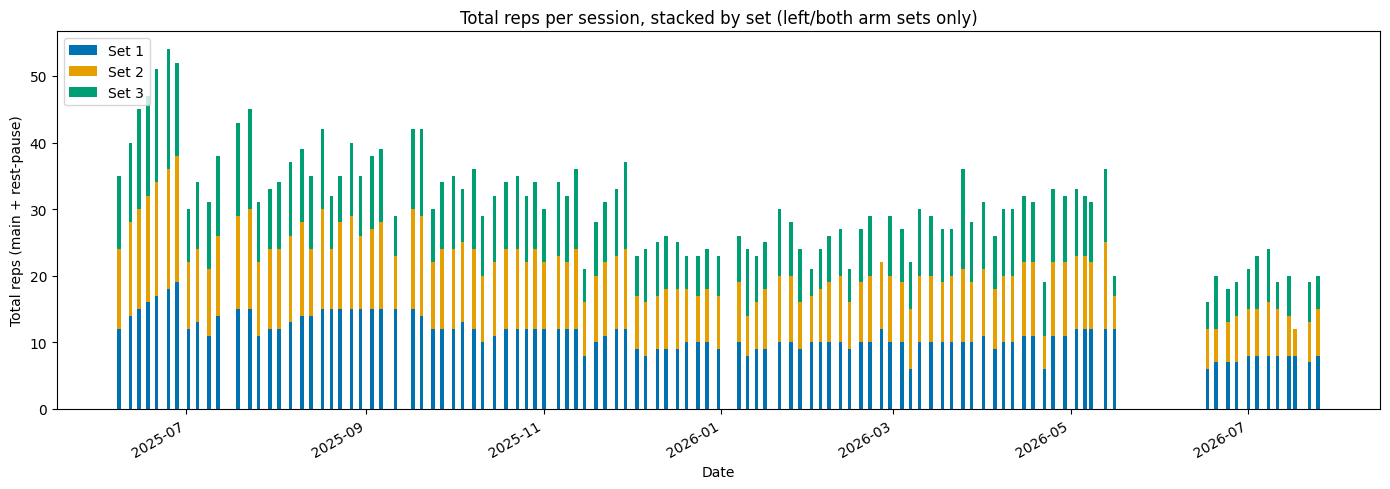

In [ ]:
# ================================
# --- Total Reps per Session ---
# ================================
# --- prep: total reps per set (reps + rest_pause_reps, drop_reps excluded) ---
dreps = df.copy()
dreps['date'] = pd.to_datetime(dreps['date'])
dreps['total_reps'] = dreps['reps'] + dreps['rest_pause_reps']
# keep only sets 1-3, and only 'both'/'left' arm rows (exclude 'right' to avoid double-counting,
# since left reps are matched by right and don't represent additional work)
dreps = dreps[dreps['set'].isin([1, 2, 3])]
dreps = dreps[dreps['arm'].isin(['both', 'left'])]
# pivot to wide: one row per date, one column per set
pivot = dreps.pivot_table(index='date', columns='set', values='total_reps', aggfunc='sum')
pivot = pivot.reindex(columns=[1, 2, 3])  # ensure consistent column order
pivot = pivot.sort_index()
# --- colorblind-safe palette (Okabe-Ito) ---
# #COLOR_SCALE
color_set1 = '#0072B2'  # blue
color_set2 = '#E69F00'  # orange
color_set3 = '#009E73'  # bluish green
# #COLOR_SCALE end
# --- plot ---
fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(pivot))
for set_num, color, label in zip([1, 2, 3],
                                   [color_set1, color_set2, color_set3],
                                   ['Set 1', 'Set 2', 'Set 3']):
    vals = pivot[set_num].fillna(0).values
    ax.bar(pivot.index, vals, bottom=bottom, color=color, label=label, width=1.2)
    bottom += vals
ax.set_xlabel('Date')
ax.set_ylabel('Total reps (main + rest-pause)')
ax.set_title('Total reps per session, stacked by set (left/both arm sets only)')
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/stacked_total_reps_by_set.png', dpi=150)
plt.show()

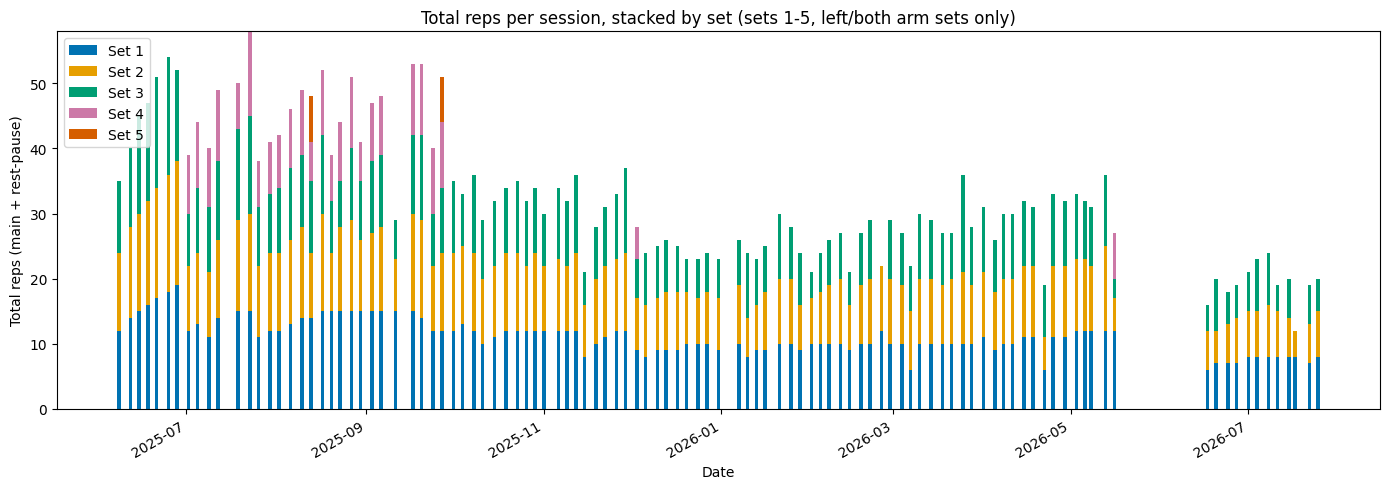

In [ ]:
# ================================
# --- Total Reps per Session, All Sets (1-5) ---
# ================================
drepsall = df.copy()
drepsall['date'] = pd.to_datetime(drepsall['date'])
drepsall['total_reps'] = drepsall['reps'] + drepsall['rest_pause_reps']

# keep only sets 1-5, and only 'both'/'left' arm rows (exclude 'right' to avoid double-counting)
drepsall = drepsall[drepsall['set'].isin([1, 2, 3, 4, 5])]
drepsall = drepsall[drepsall['arm'].isin(['both', 'left'])]

# pivot to wide: one row per date, one column per set
pivot_all = drepsall.pivot_table(index='date', columns='set', values='total_reps', aggfunc='sum')
pivot_all = pivot_all.reindex(columns=[1, 2, 3, 4, 5])
pivot_all = pivot_all.sort_index()

# --- colorblind-safe palette (Okabe-Ito), extended to 5 sets ---
# #COLOR_SCALE
color_set1 = '#0072B2'  # blue
color_set2 = '#E69F00'  # orange
color_set3 = '#009E73'  # bluish green
color_set4 = '#CC79A7'  # reddish purple
color_set5 = '#D55E00'  # vermillion
# #COLOR_SCALE end

# --- plot ---
fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(pivot_all))
for set_num, color, label in zip([1, 2, 3, 4, 5],
                                   [color_set1, color_set2, color_set3, color_set4, color_set5],
                                   ['Set 1', 'Set 2', 'Set 3', 'Set 4', 'Set 5']):
    vals = pivot_all[set_num].fillna(0).values
    ax.bar(pivot_all.index, vals, bottom=bottom, color=color, label=label, width=1.2)
    bottom += vals

ax.set_xlabel('Date')
ax.set_ylabel('Total reps (main + rest-pause)')
ax.set_title('Total reps per session, stacked by set (sets 1-5, left/both arm sets only)')
ax.legend(loc='upper left')

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/stacked_total_reps_all_sets.png', dpi=150)
plt.show()

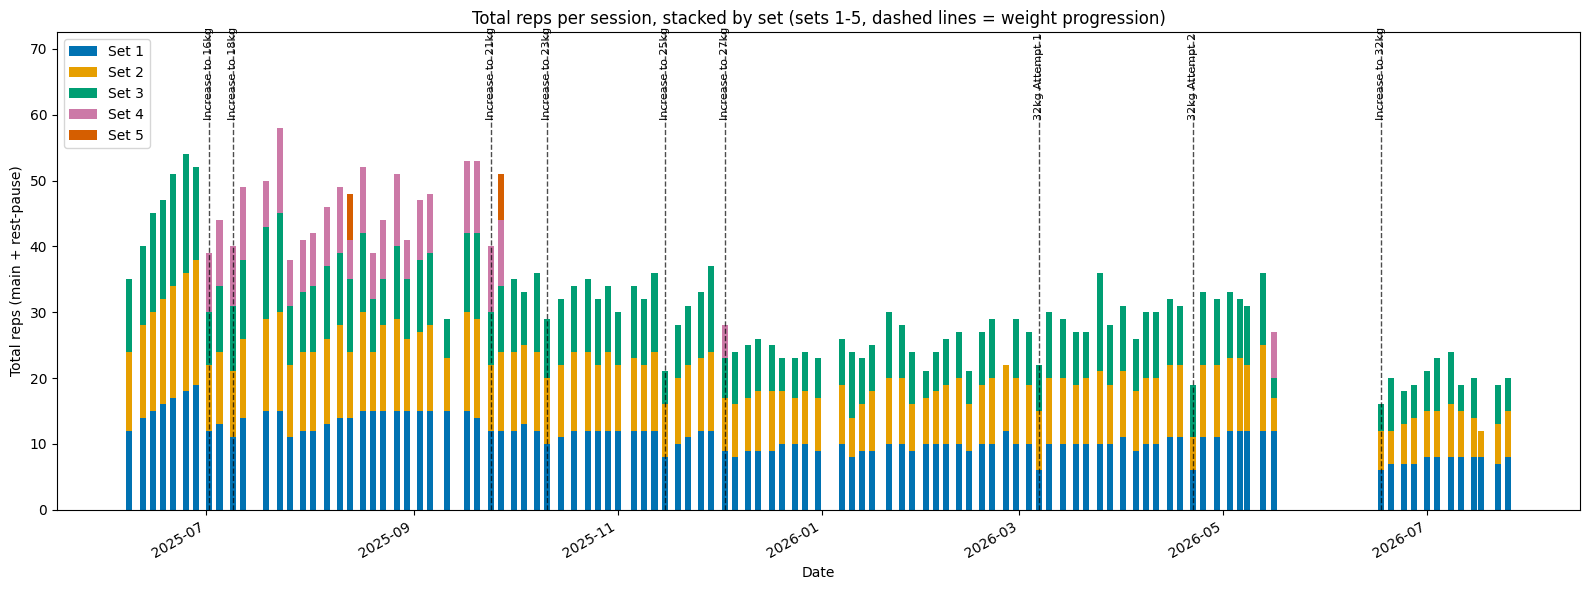

In [ ]:
# ================================================================
# --- Total Reps per Session (All Sets 1-5), flagging for weight progression ---
# ================================================================

# --- weight progression flags (based on set 1 weight) ---

dset1 = df[df['set'] == 1].copy()
dset1['date'] = pd.to_datetime(dset1['date'])
dset1.sort_values('date', inplace=True)
dset1.reset_index(drop=True, inplace=True)
prev_weight = dset1['weight'].shift(1)
running_max_before = prev_weight.cummax()  # highest weight ever reached strictly before this row
is_increase = dset1['weight'] > prev_weight               # weight went up vs. the immediately prior date
is_new_max = dset1['weight'] > running_max_before          # never reached this high before
is_32 = dset1['weight'] == 32
flag_mask = is_increase & (is_new_max | is_32)
flag_mask = flag_mask.fillna(False)
flags = dset1.loc[flag_mask, ['date', 'weight']].copy()
# label the three 32kg events specifically; everything else gets a generic label
flags['label'] = flags['weight'].apply(lambda w: f'Increase to {int(w)}kg')
attempt_32_idx = flags.index[flags['weight'] == 32]
attempt_labels = ['32kg Attempt 1', '32kg Attempt 2', 'Increase to 32kg']
for i, idx in enumerate(attempt_32_idx):
    flags.loc[idx, 'label'] = attempt_labels[i] if i < len(attempt_labels) else f'32kg attempt {i+1}'

# --- plot ---

fig, ax = plt.subplots(figsize=(16, 6))
bottom = np.zeros(len(pivot_all))
for set_num, color, label in zip([1, 2, 3, 4, 5],
                                   [color_set1, color_set2, color_set3, color_set4, color_set5],
                                   ['Set 1', 'Set 2', 'Set 3', 'Set 4', 'Set 5']):
    vals = pivot_all[set_num].fillna(0).values
    ax.bar(pivot_all.index, vals, bottom=bottom, color=color, label=label, width=1.8)
    bottom += vals
ymax = bottom.max()
for _, row in flags.iterrows():
    ax.axvline(row['date'], color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=4)
    ax.text(row['date'], ymax * 1.02, row['label'],
            rotation=90, va='bottom', ha='center', fontsize=8, color='black')
ax.set_xlabel('Date')
ax.set_ylabel('Total reps (main + rest-pause)')
ax.set_title('Total reps per session, stacked by set (sets 1-5, dashed lines = weight progression)')
ax.legend(loc='upper left')
ax.set_ylim(0, ymax * 1.25)  # headroom for labels
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/stacked_total_reps_all_sets_with_progression.png', dpi=150)
plt.show()

## Modeling: What Actually Predicts Rep Performance

The visualizations above show the shape of my progression through each weight tier, the sets 2/3 zigzag-then-catch-up pattern, and the toll of the 32kg jumps. This section asks why: which of the things I actually track (rest-pause reps, drop sets, exercise order, days between sessions, bodyweight, jump size) genuinely move the needle on how many reps I get, and which are just noise I've been telling myself a story about.

I'm treating this as an inference problem, not a prediction problem. With ~13 months of data and only a handful of true progression events, there isn't enough here to reliably forecast future performance. However there's plenty to ask, "does this variable's effect hold up once everything else is accounted for?" I build the model iteratively: start with the obvious session-level features, then add refinements (a lagged rep count for momentum, a flag for first sessions at a new weight, depth into the current weight block) as the residuals reveal patterns the simpler versions missed. Each step is a genuine test of a hypothesis from my training log, not just a tuning exercise.

In [ ]:
#Engineer a bodyweight variable that approximates my weight increase

#Note-- I do not track my bodyweight daily, but I do know that I weighed approximately 70kg in June 2025, and that I weigh slightly
#       above 76kg now in July 2026. The bodyweight variable created here considers that adults can naturally gain 0.5 kg of muscle 
#       per month on average.

df['date'] = pd.to_datetime(df['date'])

# reference: first month in the dataset, and starting bodyweight
start_period = df['date'].min().to_period('M')
start_weight = 70.0
max_weight = 76.0
monthly_gain = 0.5

# number of calendar-month changes since the start (0 in the first month, 1 the next, etc.)
months_elapsed = (df['date'].dt.to_period('M') - start_period).apply(lambda x: x.n)

df['bodyweight'] = (start_weight + months_elapsed * monthly_gain).clip(upper=max_weight)

In [ ]:
#Confirm bodyweight variable creation
df.groupby(df['date'].dt.to_period('M'))['bodyweight'].first()

date
2025-06    70.0
2025-07    70.5
2025-08    71.0
2025-09    71.5
2025-10    72.0
2025-11    72.5
2025-12    73.0
2026-01    73.5
2026-02    74.0
2026-03    74.5
2026-04    75.0
2026-05    75.5
2026-06    76.0
2026-07    76.0
Freq: M, Name: bodyweight, dtype: float64

In [ ]:
# ============================================================
# 1. Session-level table, built off Set 1 as the primary indicator
# ============================================================
df['date'] = pd.to_datetime(df['date'])

dset1 = df[(df['set'] == 1) & (df['arm'].isin(['both', 'left']))].copy()
dset1 = dset1.sort_values('date').reset_index(drop=True)
dset1['total_reps'] = dset1['reps'] + dset1['rest_pause_reps']

sessions = dset1[['date', 'weight', 'total_reps', 'exercise_order']].copy()

# --- rest-pause / drop flags: did ANY set that session use it (not just set 1) ---
rp_by_date = df.groupby('date')['rest_pause_reps'].max().gt(0)
drop_by_date = df.groupby('date')['drop_reps'].max().gt(0)

sessions['rest_pause_flag'] = sessions['date'].map(rp_by_date).astype(int)
sessions['drop_set_flag'] = sessions['date'].map(drop_by_date).astype(int)

# --- days since last bayesian curl session ---
sessions['days_since_last'] = sessions['date'].diff().dt.days

# --- weight jump vs previous session, and deload flag ---
sessions['weight_prev'] = sessions['weight'].shift(1)
sessions['weight_jump'] = sessions['weight'] - sessions['weight_prev']
sessions['deload_flag'] = (sessions['weight_jump'] < 0).astype(int)

# --- bodyweight (reuse the logic from before, joined on date) ---
start_period = df['date'].min().to_period('M')
months_elapsed = (sessions['date'].dt.to_period('M') - start_period).apply(lambda x: x.n)
sessions['bodyweight'] = (70.0 + months_elapsed * 0.5).clip(upper=76.0)

# --- days since return from the 1-month basic-curls break ---
break_end_date = pd.Timestamp('2026-06-17')
sessions['days_since_break'] = (sessions['date'] - break_end_date).dt.days
sessions['days_since_break'] = sessions['days_since_break'].clip(lower=0)  # 0 for anything before/at the break

# --- exercise_order as numeric (0 = first, 1 = second) ---
sessions['exercise_order_num'] = (sessions['exercise_order'] == 'second').astype(int)

# first row has no "previous session" info — drop it for modeling
sessions_model = sessions.dropna(subset=['days_since_last', 'weight_jump']).copy()

sessions_model.head(10)

,date,weight,total_reps,exercise_order,rest_pause_flag,drop_set_flag,days_since_last,weight_prev,weight_jump,deload_flag,bodyweight,days_since_break,exercise_order_num
1,2025-06-12,11,14,second,0,0,4.0,11.0,0.0,0,70.0,0,1
2,2025-06-15,11,15,second,0,0,3.0,11.0,0.0,0,70.0,0,1
3,2025-06-18,11,16,second,0,0,3.0,11.0,0.0,0,70.0,0,1
4,2025-06-21,11,17,second,0,0,3.0,11.0,0.0,0,70.0,0,1
5,2025-06-25,11,18,second,0,0,4.0,11.0,0.0,0,70.0,0,1
6,2025-06-28,11,19,second,1,0,3.0,11.0,0.0,0,70.0,0,1
7,2025-07-02,16,12,first,0,0,4.0,11.0,5.0,0,70.5,0,0
8,2025-07-05,16,13,first,0,0,3.0,16.0,0.0,0,70.5,0,0
9,2025-07-09,18,11,first,0,0,4.0,16.0,2.0,0,70.5,0,0
10,2025-07-12,16,14,first,0,0,3.0,18.0,-2.0,1,70.5,0,0


In [ ]:
# ============================================================
# Feature set for inference
# ============================================================
feature_cols = [
    'weight',              # current working weight
    'weight_jump',         # change vs previous session (signed: neg = deload, pos = increase)
    'rest_pause_flag',
    'drop_set_flag',
    'exercise_order_num',
    'days_since_last',
    'days_since_break',
    'bodyweight',
]

X = sessions_model[feature_cols].copy()
y = sessions_model['total_reps'].copy()

# standardize continuous predictors so coefficients are comparable in magnitude
# (flags stay 0/1, so we leave those alone)
continuous_cols = ['weight', 'weight_jump', 'days_since_last', 'days_since_break', 'bodyweight']
X_std = X.copy()
for col in continuous_cols:
    X_std[col] = (X[col] - X[col].mean()) / X[col].std()

X_std = sm.add_constant(X_std)

# ============================================================
# OLS with heteroskedasticity/autocorrelation-robust SEs
# (session data is a time series, so plain OLS SEs would understate uncertainty)
# ============================================================
model = sm.OLS(y, X_std).fit(cov_type='HAC', cov_kwds={'maxlags': 2})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             total_reps   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     86.63
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           5.42e-41
Time:                        11:36:18   Log-Likelihood:                -146.29
No. Observations:                 107   AIC:                             310.6
Df Residuals:                      98   BIC:                             334.6
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 11.1968      0

### Model 1: Baseline Session-Level Regression

The first pass fit `total_reps` (Set 1 reps + rest-pause reps) against eight session-level features: current `weight`, `weight_jump`, `rest_pause_flag`, `drop_set_flag`, `exercise_order_num`, `days_since_last`, `days_since_break`, and `bodyweight`. Standard errors are HAC-adjusted (2 lags) to account for autocorrelation across consecutive sessions.

**Fit:** R² = 0.869 — a strong initial fit, though this is expected given `weight` alone captures most of the variation in reps.

**Clearly significant (p < 0.001):**
- **`weight`** (coef -3.61): heavier working weight predicts fewer reps, as expected from the basic strength curve.
- **`bodyweight`** (coef +1.25): heavier bodyweight predicts more reps at a given weight, which is consistent with the muscle-growth story, though this coefficient is later revisited in Model 4.

**Marginal (p between 0.05-0.10):**
- **`weight_jump`** (coef -0.23, p=0.080): a hint that bigger jumps to the next weight tier cost a few reps on the way up.
- **`days_since_last`** (coef -0.11, p=0.054): counterintuitively, more rest before a session predicts *fewer* reps rather than more, which is worth investigating further rather than taking at face value.

**Not distinguishable from zero:**
- `rest_pause_flag`, `drop_set_flag`, `exercise_order_num`, `days_since_break` did not show a reliable effect in this baseline model.

**Diagnostic flag:** Durbin-Watson = 1.045, well below the ~2.0 that would indicate no leftover autocorrelation. This signals that today's rep count likely depends on the previous session's result in a way this model isn't capturing.

In [ ]:
# Does the number of reps in the previous session have an influence?

# --- add lagged outcome (previous session's total_reps) ---
sessions_model2 = sessions_model.copy()
sessions_model2['total_reps_lag1'] = sessions_model2['total_reps'].shift(1)

# this introduces one more NaN at the top of the (already-trimmed) series
sessions_model2 = sessions_model2.dropna(subset=['total_reps_lag1']).copy()

feature_cols2 = [
    'weight',
    'weight_jump',
    'rest_pause_flag',
    'drop_set_flag',
    'exercise_order_num',
    'days_since_last',
    'days_since_break',
    'bodyweight',
    'total_reps_lag1',
]

X2 = sessions_model2[feature_cols2].copy()
y2 = sessions_model2['total_reps'].copy()

continuous_cols2 = ['weight', 'weight_jump', 'days_since_last', 'days_since_break',
                     'bodyweight', 'total_reps_lag1']
X2_std = X2.copy()
for col in continuous_cols2:
    X2_std[col] = (X2[col] - X2[col].mean()) / X2[col].std()

X2_std = sm.add_constant(X2_std)

model2 = sm.OLS(y2, X2_std).fit(cov_type='HAC', cov_kwds={'maxlags': 2})
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             total_reps   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     166.4
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.71e-54
Time:                        15:11:17   Log-Likelihood:                -124.45
No. Observations:                 106   AIC:                             268.9
Df Residuals:                      96   BIC:                             295.5
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 11.1481      0

### Model 2: Adding a Lagged Outcome Term

Model 1's Durbin-Watson statistic (1.045) signaled leftover autocorrelation, meaning today's reps likely depend on how the previous session went, in a way the baseline model wasn't capturing. Model 2 adds `total_reps_lag1` (the previous session's total reps) to test that directly.

**Fit:** R² improved to 0.911 (from 0.869), and Durbin-Watson jumped to 2.133, right around the mark that indicates the autocorrelation problem has been resolved.

**Clearly significant (p < 0.01):**
- **`total_reps_lag1`** (coef +1.29, p<0.001): strongly significant, and the coefficient is *above* 1 on a standardized scale, suggesting that a good previous session predicts an even better current one, suggesting momentum compounds rather than just persists.
- **`weight`** (coef -1.86): still significant, though noticeably smaller than in Model 1. Some of what `weight` was capturing before was actually this momentum effect.
- **`weight_jump`** (coef -0.74, p=0.002): now clearly significant (up from marginal in Model 1). Bigger tier jumps convincingly cost reps on the session they're taken.
- **`bodyweight`** (coef +0.64, p=0.019): still significant, though also shrunk from Model 1.

**No longer significant:**
- **`days_since_break`** (p=0.906): dropped to essentially zero. This confirms it was riding on the coattails of the momentum effect, not a real standalone recovery-from-break signal.

**Still not distinguishable from zero:**
- `rest_pause_flag`, `drop_set_flag`, `exercise_order_num` — consistent with Model 1, no reliable effect from any of these "technique" variables.

**Still marginal:**
- **`days_since_last`** (coef -0.14, p=0.028): actually got *more* significant than in Model 1. More days between sessions predicts fewer reps, even controlling for how well the last session went. This isn't just an artifact of the post-break period.

**Diagnostic flag:** Omnibus/Jarque-Bera are now significant (p<0.001), with skew -0.93. The residuals have a longer left tail, meaning some sessions notably underperform what the model predicts. This motivated pulling and inspecting the worst-residual sessions directly.

### Pulling and examining the worst residuals:
Which specific sessions did the model got most wrong, and why. 

`resid` = `actual` - `predicted`, so sorting ascending and taking the head gives the 10 sessions where I underperformed the model's expectation the most. Merging in notes from the full df (any set, not just set 1) was to check if they are all explained by something I already logged" (injury, fatigue, equipment issue). That merge found exactly one date (2026-05-13, "tired, wrist trouble") and nine unexplained dates.

In [ ]:
# --- pull residuals and match back to dates ---
sessions_model2['fitted'] = model2.fittedvalues
sessions_model2['resid'] = model2.resid

# sort by most negative residual first (biggest underperformance vs. predicted)
worst = sessions_model2[['date', 'weight', 'total_reps', 'fitted', 'resid']].sort_values('resid').head(10)

# pull any notes from the original df for those dates (any set, not just set 1)
notes = df[df['note'].notna()][['date', 'set', 'note']]

worst_with_notes = worst.merge(notes, on='date', how='left')
print(worst_with_notes.to_string(index=False))

      date  weight  total_reps    fitted     resid  set                 note
2025-07-02      16          12 14.594310 -2.594310  NaN                  NaN
2025-07-26      18          11 13.412262 -2.412262  NaN                  NaN
2026-02-25      21          12 14.366403 -2.366403  NaN                  NaN
2026-01-10      27           8  9.863749 -1.863749  NaN                  NaN
2025-11-15      25           8  9.838925 -1.838925  NaN                  NaN
2026-04-05      27           9 10.412354 -1.412354  NaN                  NaN
2025-07-09      18          11 12.385359 -1.385359  NaN                  NaN
2025-12-06      27           8  9.203644 -1.203644  NaN                  NaN
2026-05-13      25          12 13.164062 -1.164062  1.0                tired
2026-05-13      25          12 13.164062 -1.164062  2.0 tired, wrist trouble
2026-05-13      25          12 13.164062 -1.164062  3.0                tired
2025-08-02      18          12 13.054841 -1.054841  NaN                  NaN

### Checking `change_in_weight`:
Another hypothesis was tested: that a change to a new weight costs reps beyond what the linear `weight_jump`  captures, or in other words, a one-time penalty rather than a jump-size-scaled effect. This check builds a simple flag (weight != previous session's weight) and cross-references it against the worst-residual dates, to see if the pattern holds up before committing to adding it as a real feature.

That check came back mixed (6 of 10 flagged True), prompting its inclusion into Model 3.

In [ ]:
# flag whether each of these dates was the first session at that weight
sessions_model2['change_in_weight'] = sessions_model2['weight'] != sessions_model2['weight'].shift(1)

worst_check = sessions_model2[sessions_model2['date'].isin(worst_with_notes['date'])][
    ['date', 'weight', 'total_reps', 'resid', 'change_in_weight']
]
print(worst_check.sort_values('resid'))

         date  weight  total_reps     resid  change_in_weight
7  2025-07-02      16          12 -2.594310              True
13 2025-07-26      18          11 -2.412262              True
72 2026-02-25      21          12 -2.366403              True
59 2026-01-10      27           8 -1.863749             False
44 2025-11-15      25           8 -1.838925              True
83 2026-04-05      27           9 -1.412354             False
9  2025-07-09      18          11 -1.385359              True
50 2025-12-06      27           8 -1.203644             False
94 2026-05-13      25          12 -1.164062              True
15 2025-08-02      18          12 -1.054841             False


In [ ]:
sessions_model3 = sessions_model2.copy()
sessions_model3['change_in_weight'] = (sessions_model3['weight'] != sessions_model3['weight'].shift(1)).astype(int)

feature_cols3 = [
    'weight',
    'weight_jump',
    'rest_pause_flag',
    'drop_set_flag',
    'exercise_order_num',
    'days_since_last',
    'days_since_break',
    'bodyweight',
    'total_reps_lag1',
    'change_in_weight',
]

X3 = sessions_model3[feature_cols3].copy()
y3 = sessions_model3['total_reps'].copy()

continuous_cols3 = ['weight', 'weight_jump', 'days_since_last', 'days_since_break',
                     'bodyweight', 'total_reps_lag1']
X3_std = X3.copy()
for col in continuous_cols3:
    X3_std[col] = (X3[col] - X3[col].mean()) / X3[col].std()
# first_at_weight is left as 0/1, like the other flags

X3_std = sm.add_constant(X3_std)

model3 = sm.OLS(y3, X3_std).fit(cov_type='HAC', cov_kwds={'maxlags': 2})
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:             total_reps   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     231.2
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           4.70e-62
Time:                        14:45:25   Log-Likelihood:                -114.16
No. Observations:                 106   AIC:                             250.3
Df Residuals:                      95   BIC:                             279.6
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 11.2921      0

### Model 3: Adding a "Change in Weight" Flag

Inspecting Model 2's worst-residual sessions surfaced a pattern: several of the biggest underperformances happened right after a weight change (not always a genuine progression, sometimes a light secondary day or a reverted attempt). Model 3 adds `change_in_weight`, a flag for whether this session's weight differs from the immediately preceding session's weight, to test that directly.

**Fit:** R² improved to 0.927 (from 0.911). Durbin-Watson stayed healthy at 2.078.

**Clearly significant (p < 0.01):**
- **`change_in_weight`** (coef -0.95, p<0.001): a session where the weight differs from the last one costs about 1 rep, holding everything else constant.
- **`weight`** (coef -2.14): still significant, similar magnitude to Model 2.
- **`total_reps_lag1`** (coef +1.16, p<0.001): still strongly significant, consistent with Model 2's momentum finding.
- **`weight_jump`** (coef -0.58, p=0.008): still significant, though the coefficient shrank a bit from Model 2, since some of its effect moved to `change_in_weight` now that they're properly separated.
- **`bodyweight`** (coef +0.82, p=0.006): still significant, similar to Model 2.

**Marginal:**
- **`days_since_last`** (coef -0.11, p=0.086): weakened slightly from Model 2 (p=0.028), part of its earlier signal absorbed by the new flag.

**Still not distinguishable from zero:**
- `rest_pause_flag`, `drop_set_flag`, `exercise_order_num`, `days_since_break`. Consistent across all three models now, no reliable effect from any of these variables.

**Diagnostic note:** Residual normality improved (skew moved from -0.93 in Model 2 to -0.21, Omnibus p-value up to 0.085). Model 4 goes on to add a variable for depth into the current weight block, which further clarifies the `bodyweight` coefficient. Rationale is that the number of sessions varies among `weight`, particularly at 27kg.

In [ ]:
#====================================
# Identify sustained weight-block start dates
#====================================
s_all = sessions_model3.sort_values('date').reset_index(drop=True)
s_all['weight_prev_session'] = s_all['weight'].shift(1)
candidates = s_all[s_all['weight'] != s_all['weight_prev_session']][['date', 'weight']].copy()
candidates = pd.concat([
    pd.DataFrame({'date': [s_all['date'].iloc[0]], 'weight': [s_all['weight'].iloc[0]]}),
    candidates
]).drop_duplicates(subset='date').sort_values('date').reset_index(drop=True)

blocks = []
established = candidates.loc[0, 'weight']
blocks.append({'date': candidates.loc[0, 'date'], 'weight': established})

for i in range(1, len(candidates)):
    w = candidates.loc[i, 'weight']
    if w == established:
        continue  # just returning to the current established weight, not a new event
    if i + 1 < len(candidates) and candidates.loc[i + 1, 'weight'] == established:
        continue  # abandoned: next differing session reverts right back -> skip
    # persisted forward (or this is the final, ongoing block) -> genuine new establishment
    blocks.append({'date': candidates.loc[i, 'date'], 'weight': w})
    established = w

sustained_starts = pd.DataFrame(blocks)
sustained_starts['block_id'] = range(len(sustained_starts))
sustained_starts = sustained_starts.rename(columns={'weight': 'block_weight', 'date': 'block_start_date'})
print(sustained_starts)

  block_start_date  block_weight  block_id
0       2025-06-15            11         0
1       2025-07-02            16         1
2       2025-07-26            18         2
3       2025-09-24            21         3
4       2025-10-11            23         4
5       2025-11-15            25         5
6       2025-12-03            27         6
7       2026-06-17            32         7


In [ ]:
#====================================
# Assign sessions to weight blocks, compute progress within each
#====================================

s = sessions_model3.sort_values('date').copy()
s = pd.merge_asof(s, sustained_starts, left_on='date', right_on='block_start_date', direction='backward')

# a session only "counts" toward this block's progress if its weight matches the block's weight
# (excludes light secondary days, tired-day dips, and failed 32kg attempts)
s['is_block_primary'] = (s['weight'] == s['block_weight']).astype(int)

primary = s[s['is_block_primary'] == 1].copy()
primary['days_in_block'] = (primary['date'] - primary['block_start_date']).dt.days
primary['session_num_in_block'] = primary.groupby('block_id').cumcount() + 1

s = s.merge(primary[['date', 'days_in_block', 'session_num_in_block']], on='date', how='left')

#how much work each block actually took
block_summary = primary.groupby('block_id').agg(
    weight=('block_weight', 'first'),          # the block's weight tier (constant within group)
    start_date=('block_start_date', 'first'),  # the block's start date (constant within group)
    n_primary_sessions=('session_num_in_block', 'max'),  # how many primary sessions (sessions actually performed at the block's assigned weight, excluding deviations and reverted attempts)
    total_days=('days_in_block', 'max')        # total elapsed calendar days from block start to last session
).reset_index()
print(block_summary)

   block_id  weight start_date  n_primary_sessions  total_days
0         0      11 2025-06-15                   5          13
1         1      16 2025-07-02                   5          21
2         2      18 2025-07-26                  16          56
3         3      21 2025-09-24                   5          14
4         4      23 2025-10-11                  10          32
5         5      25 2025-11-15                   5          14
6         6      27 2025-12-03                  43         164
7         7      32 2026-06-17                  12          38


In [ ]:
sessions_model4 = s.copy()
# session_num_in_block will be NaN for non-primary sessions (deviations/failed attempts) —
# fill with 0 so the model treats "not currently grinding this block" as baseline
sessions_model4['session_num_in_block'] = sessions_model4['session_num_in_block'].fillna(0)

feature_cols4 = feature_cols3 + ['session_num_in_block']

X4 = sessions_model4[feature_cols4].copy()
y4 = sessions_model4['total_reps'].copy()

continuous_cols4 = continuous_cols3 + ['session_num_in_block']
X4_std = X4.copy()
for col in continuous_cols4:
    X4_std[col] = (X4[col] - X4[col].mean()) / X4[col].std()

X4_std = sm.add_constant(X4_std)

model4 = sm.OLS(y4, X4_std).fit(cov_type='HAC', cov_kwds={'maxlags': 2})
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:             total_reps   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     210.2
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           4.48e-61
Time:                        14:47:21   Log-Likelihood:                -110.74
No. Observations:                 106   AIC:                             245.5
Df Residuals:                      94   BIC:                             277.4
Df Model:                          11                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   11.2364 

### Model 4: Adding Depth Into the Current Weight Block

As revealed earlier during EDA, 27kg sessions stretched for about 4 months at a 10-rep ceiling before suddenly jumping to 12, suggesting accumulated time at a weight matters beyond a simple first-attempt penalty. Model 4 adds `session_num_in_block`, a count of how many primary sessions (sessions actually performed at the block's assigned weight, excluding deviations and reverted attempts) have occurred since arriving at the current weight tier.

**Fit:** R squared improved slightly to 0.931 (from 0.927). Durbin-Watson held steady at 1.939.

**The key finding here is a displacement, not just a new significant term.** Adding `session_num_in_block` caused `bodyweight` to collapse from significant (coef 0.82, p=0.006 in Model 3) to not significant at all (coef 0.25, p=0.392). Since bodyweight and time spent in a block both increase steadily together, this suggests the earlier bodyweight effect was partly standing in for accumulated practice at a given weight, rather than reflecting muscle mass gain on its own.

**Clearly significant (p < 0.01):**
- `session_num_in_block` (coef 0.31, p=0.003): more sessions logged at the current weight predicts more reps, a direct measure of within-tier progress.
- `weight` (coef -1.77): still significant, similar to prior models.
- `total_reps_lag1` (coef 1.13, p<0.001): still strongly significant, consistent with Models 2 and 3.
- `change_in_weight` (coef -0.79, p=0.001): still significant, similar magnitude to Model 3.
- `weight_jump` (coef -0.59, p=0.001): still significant, essentially unchanged from Model 3.

**No longer significant:**
- `bodyweight` (p=0.392): as noted above, its earlier signal appears to have been substantially explained by `session_num_in_block`.

**Still not distinguishable from zero:**
- `rest_pause_flag`, `drop_set_flag`, `exercise_order_num`, `days_since_last`, `days_since_break`. Consistent with prior models: none of the technique or recovery-timing variables show a reliable effect once weight, momentum, and block depth are accounted for.

### Using Model 4 to Answer the 32kg Question

The original motivating question was whether 8 reps at 32kg reflects genuine underperformance, or is simply what the load penalty should look like at this stage. Model 4 makes it possible to answer this directly by holding every other factor at a fixed, realistic value and varying only the weight.

The approach: build one hypothetical "typical session" (no weight jump that day, no rest-pause or drop set, bayesian curl done first, a normal rest gap, current 76kg bodyweight, not currently changing weight, and depth into the block set to 12 sessions in, matching where I actually am at 32kg right now). Then swap only the `weight` value between 27 and 32, standardize each hypothetical row the same way the training data was standardized, and run both through the fitted model's coefficients.

This is a more honest comparison than an idealized "fully settled in" estimate would be, since it asks the model, at the exact same amount of accumulated practice at a weight, how many reps should I expect at 27kg versus 32kg. That isolates the pure effect of the heavier load itself, at a point in the learning curve that actually matches where I am today, rather than comparing against a hypothetical future state.

**Result:** predicted 10.76 reps at 27kg versus 9.14 reps at 32kg, at matched depth, a gap of about 1.6 reps. Compared to the actual current 8 reps at 32kg, this suggests performance is tracking close to the model's expectation rather than lagging behind it, and that the earlier discouragement from repeated 6-rep sets during the two failed attempts reflected the expected new-tier and early-block penalties, not a sign that 32kg wasn't achievable.

In [ ]:
# ============================================================
# Predict expected reps at 27kg vs 32kg, now holding "depth into the
# block" constant at 12 sessions in (my actual current point at 32kg)
# ============================================================

typical4 = {
    'weight_jump': 0,
    'rest_pause_flag': 0,
    'drop_set_flag': 0,
    'exercise_order_num': 0,
    'days_since_last': sessions_model4['days_since_last'].median(),
    'days_since_break': 0,
    'bodyweight': 76.0,
    'total_reps_lag1': sessions_model4.loc[sessions_model4['is_block_primary'] == 1, 'total_reps'].mean(),
    'change_in_weight': 0,
    'session_num_in_block': 12,   # matches where I am in the 32kg block right now
}

def predict_reps4(weight_value, overrides=typical4):
    row = overrides.copy()
    row['weight'] = weight_value

    row_std = row.copy()
    for col in continuous_cols4:
        row_std[col] = (row[col] - X4[col].mean()) / X4[col].std()

    row_std['const'] = 1.0
    x_vec = np.array([row_std[c] for c in X4_std.columns])
    return model4.predict(x_vec)[0]

pred_27_at12 = predict_reps4(27)
pred_32_at12 = predict_reps4(32)

print(f"Predicted reps at 27kg, 12 sessions into that block: {pred_27_at12:.2f}")
print(f"Predicted reps at 32kg, 12 sessions into that block: {pred_32_at12:.2f}")
print(f"Predicted gap at matched depth: {pred_27_at12 - pred_32_at12:.2f} reps")

Predicted reps at 27kg, 12 sessions into that block: 10.76
Predicted reps at 32kg, 12 sessions into that block: 9.14
Predicted gap at matched depth: 1.62 reps


## Summary

This analysis set out to answer a few specific questions about my bayesian curl progress over 13 months, and the modeling work landed on some clear answers.

**What actually predicts performance:** Working weight and depth into the current weight block are the two dominant, consistently significant factors across every model iteration. How many reps I did last session also matters a great deal, performance carries real momentum from one session to the next, more than a simple day-to-day average would suggest. The size of a weight jump and whether a session represents a change from the previous weight both carry a real, measurable cost, separate from each other: a bigger jump costs more reps on the day it's taken, and simply changing weight at all (even a planned light day) costs about a rep, independent of jump size.

**What doesn't show a reliable effect:** Rest-pause reps, drop sets, and whether bayesian curls were the first or second bicep exercise of the day never came out significant, in any model. At this sample size, these techniques aren't detectably moving the needle on reps, one way or the other. Days since the one-month break also washed out once the lagged rep count was in the model, the earlier apparent effect was really the momentum term in disguise. Days since last session showed a persistent but only marginal signal (more rest predicting slightly fewer reps), worth continued attention but not a strong conclusion.

**The bodyweight finding was more subtle than it first appeared.** Bodyweight looked like a real, independent predictor in the early models, but once `session_num_in_block` (accumulated sessions at the current weight) was added, bodyweight's effect mostly disappeared. This suggests that what looked like a muscle-growth effect was substantially standing in for accumulated practice time at a given weight, rather than reflecting added mass on its own. That's a genuinely useful correction: getting stronger at a weight looks less about simply gaining mass, and more about sessions logged there.

**On the specific 32kg question explored along the way:** the model puts the pure load penalty of 32kg versus 27kg, at matched depth into the block, at around 1.6 reps, not the roughly 4-rep gap it felt like in the moment. Current performance (8 reps) is tracking close to what the model expects at this point (about 9), suggesting the discouraging 6-rep sets during both failed attempts were the expected new-tier and early-block cost, not a sign 32kg wasn't achievable. The original instinct that 8 reps under-sold the actual ceiling looks right, and the data points toward something closer to 9-10 reps as a reasonable target going forward, in line with the ~2-rep-per-tier pattern seen at every prior weight increase.

**Caveats worth keeping in mind:** this is an inference exercise on a modest, single-subject dataset, not a validated predictive model, the coefficients describe patterns in this specific history and shouldn't be over-generalized. A handful of variables I couldn't fully separate (bodyweight and time, in particular) remain somewhat entangled given how both trend upward together over 13 months. And several plausible factors, rest time between sessions, sleep, general fatigue, aren't tracked at all, so some of the remaining unexplained variance is very likely just real, unmeasured, session-to-session life.

**Next Steps:** I do not only do bayesian curls. My arm workout days always follow a chest and back day. Performance on back exercises are likely to influence bicep performance. Future models will merge back data and create a more comprehensive model.

## Model Variable Dictionary

| Variable | Description |
|---|---|
| `date` | Date of the session (Set 1, left/both arm rows only). |
| `weight` | Set 1 working weight (kg) for that session. |
| `total_reps` | Set 1 reps + rest_pause_reps for that session (the model's outcome variable). |
| `exercise_order` | Whether bayesian curl was the `first` or `second` bicep exercise that day (raw text). |
| `exercise_order_num` | Numeric encoding of `exercise_order`: 0 = first, 1 = second. |
| `rest_pause_flag` | 1 if any set that session used a rest-pause, 0 otherwise. |
| `drop_set_flag` | 1 if any set that session used a drop set, 0 otherwise. |
| `days_since_last` | Days elapsed since the previous bayesian curl session. |
| `weight_prev` | Set 1 weight from the previous session (used to derive `weight_jump`). |
| `weight_jump` | Change in weight vs. the previous session (`weight` minus `weight_prev`). Positive = increase, negative = deload. |
| `deload_flag` | 1 if `weight_jump` is negative (weight decreased vs. last session), 0 otherwise. |
| `bodyweight` | Estimated bodyweight (kg) for that date, stepping up 0.5kg per calendar month from 70kg to a 76kg cap. |
| `days_since_break` | Days since returning from the one-month basic-curls break (2026-06-17), clipped at 0 for any date before/at the break. |
| `total_reps_lag1` | `total_reps` from the previous session (captures session-to-session momentum). |
| `change_in_weight` | 1 if this session's weight differs from the immediately preceding session's weight, 0 otherwise. Originally named `first_at_weight`; flags any weight change, not just true first-ever arrivals at a weight (e.g. also fires on return from a one-off light day or a reverted attempt). |
| `block_start_date` | Start date of the current sustained weight block (from `sustained_starts`), i.e. the most recent weight that was genuinely established, not abandoned. |
| `block_weight` | The weight (kg) assigned to the current sustained block. |
| `block_id` | Sequential ID of the sustained weight block (0 = 11kg, 1 = 16kg, ... 7 = 32kg). |
| `is_block_primary` | 1 if this session's weight matches its block's assigned weight (a genuine working session at that tier), 0 if it's a deviation (light secondary day, tired-day dip, or a reverted attempt at the next tier). |
| `days_in_block` | Days elapsed from the block's start date to this session (only computed for primary sessions). |
| `session_num_in_block` | Count of primary sessions since arriving at the current weight block (1, 2, 3...); 0 for non-primary (deviation) sessions. |
| `fitted` | Model-predicted `total_reps` for that session (from a given model's `.fittedvalues`). |
| `resid` | Residual: actual `total_reps` minus `fitted` (positive = overperformed, negative = underperformed). |

## Tableau Exports

In [ ]:
# ============================================================
# Export: Model data (for Tableau)
# ============================================================

#adding fitted and residual values
sessions_model4['fitted'] = model4.fittedvalues
sessions_model4['resid'] = model4.resid

sessions_model4.to_csv('model_data.csv', index=False)

In [ ]:
# ============================================================
# Export: EDA chart data (for Tableau)
# ============================================================

# --- Set 1, with weight and reps over time ---
dset1[['date', 'set', 'weight', 'reps', 'arm', 'exercise_order']].to_csv(
    'eda_set1.csv', index=False
)

# --- Sets 2 and 3, individually and averaged ---
dset2[['date', 'set', 'weight', 'reps', 'arm', 'exercise_order']].to_csv(
    'eda_set2.csv', index=False
)
dset3[['date', 'set', 'weight', 'reps', 'arm', 'exercise_order']].to_csv(
    'eda_set3.csv', index=False
)
dset23_avg.to_csv('eda_sets23_avg.csv', index=False)

# --- Stacked total-reps-per-session data (long format) ---
pivot_all_long = pivot_all.reset_index().melt(id_vars='date', var_name='set', value_name='total_reps')
pivot_all_long = pivot_all_long.dropna(subset=['total_reps'])
pivot_all_long.to_csv('eda_stacked_reps_long.csv', index=False)

# --- Weight progression flags ---
flags.to_csv('eda_progression_flags.csv', index=False)

# --- Rest-pause / drop-set date flags ---
import pandas as pd
rp_drop_flags = pd.DataFrame({
    'date': list(rp_only_dates) + list(drop_only_dates) + list(both_dates),
    'flag_type': (['rest_pause_only'] * len(rp_only_dates) +
                  ['drop_set_only'] * len(drop_only_dates) +
                  ['both'] * len(both_dates))
})
rp_drop_flags.to_csv('eda_rp_drop_flags.csv', index=False)